<center>

# __Fairness in the Lab__

<br>

Dr. [Jose Maria Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

Ms. [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

__3 March 2026__
 
__Explainable and Trustworthy AI__

<br>

![MIA.png](MIA.png)

</center>

# **1. Introduction**

This interactive tutorial includes supplementary material for the second TAI in the Lab hands-on session (I5. "Fairness in the Lab") in the Subject **Explainable and Trustworthy AI** (Master in Artificial Intelligence). The session is leaded by [Jose M. Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral) and [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/) at USC, [Samuel Suárez Marcote](https://pdi.udc.es/es/File/Pdi/UA4VL![imagen.png](attachment:imagen.png)) at UDC, and [David Nicholas Olivieri Cecchi](https://www.uvigo.gal/es/universidad/administracion-personal/pdi/david-nicholas-olivieri-cecchi) at UVigo.

It is worth noting that the following materials are largely based on documentation and examples available at the [Fairlearn website](https://fairlearn.org/).

# **2. Settings**

This section is aimed for installing software and loading the required Python libraries.

In [1]:
## this code is developed by Jose Maria Alonso-Moral

import os

os.system("pip install -U scikit-image --quiet")

# Fairlearn
os.system("pip install fairlearn --quiet")

0

In [2]:
## this code is developed by Jose Maria Alonso-Moral
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pprint import pprint

from sklearn import metrics as skm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from fairlearn.datasets import fetch_adult
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import DemographicParity, ErrorRate, GridSearch
from fairlearn.metrics import (
    MetricFrame, selection_rate, selection_rate_difference, equalized_odds_ratio, equalized_odds_difference, demographic_parity_difference, demographic_parity_ratio, false_negative_rate, false_positive_rate, true_negative_rate, true_positive_rate, count
)

# **3. Fairlearn**

In this section, we see first how to assess the fairness of a dataset by means of the [Fairlearn software](https://fairlearn.org/).

We will work with the well-known [Adult dataset](https://archive.ics.uci.edu/ml/datasets/Adult). The prediction task is to determine whether a person makes over $50K a year (binary classification), regarding the 1994 USA Census database. This dataset contains 14 attributes (including some sensitive attributes such as sex, race or education): 

* **age**
* **workclass** (Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked)
* **fnlwgt**
* **education** (Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool)
* **education-num**
* **marital-status** (Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse)
* **occupation** (Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces)
* **relationship** (Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried)
* **race** (White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black)
* **sex** (Female, Male)
* **capital-gain**
* **capital-loss**
* **hours-per-week**
* **native-country** (United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands)

In [3]:
# Load data
adult_data = fetch_openml(data_id=1590, as_frame=True)
X = pd.get_dummies(adult_data.data)
print(X)
y_true = (adult_data.target == '>50K') * 1
sex = adult_data.data['sex']
print(sex.value_counts())
race = adult_data.data['race']
print(race.value_counts())
education = adult_data.data['education']
print(education.value_counts())

       age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week  \
0       25  226802              7             0             0              40   
1       38   89814              9             0             0              50   
2       28  336951             12             0             0              40   
3       44  160323             10          7688             0              40   
4       18  103497             10             0             0              30   
...    ...     ...            ...           ...           ...             ...   
48837   27  257302             12             0             0              38   
48838   40  154374              9             0             0              40   
48839   58  151910              9             0             0              40   
48840   22  201490              9             0             0              20   
48841   52  287927              9         15024             0              40   

       workclass_Federal-go

In [4]:
X.head(n=10)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,198693,6,0,0,30,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
6,29,227026,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,63,104626,15,3103,0,32,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
8,24,369667,10,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
9,55,104996,4,0,0,10,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


Running the code below, you can visualize the fraction of males and females who earn over $50k.

        selection_rate  true_positive_rate
sex                                       
Female        0.109251                 1.0
Male          0.303767                 1.0
Difference:
selection_rate        0.194516
true_positive_rate    0.000000
dtype: float64
Ratio:
selection_rate        0.359655
true_positive_rate    1.000000
dtype: float64


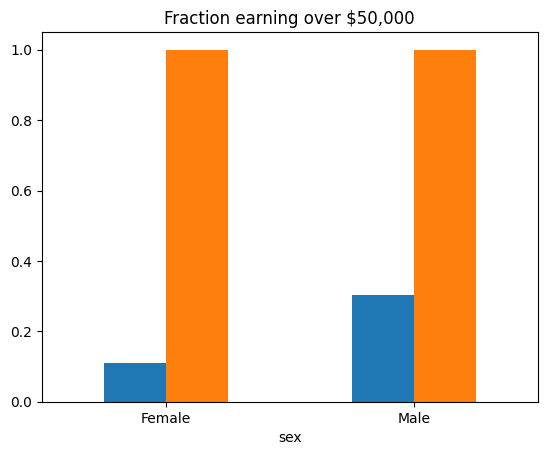

In [5]:
metrics_dict = {"selection_rate": selection_rate, "true_positive_rate": true_positive_rate}
selection_rates = MetricFrame(
    metrics=metrics_dict, y_true=y_true, y_pred=y_true, sensitive_features=sex
)
print(selection_rates.by_group)
print("Difference:")
print(selection_rates.difference())
print("Ratio:")
print(selection_rates.ratio())
fig = selection_rates.by_group.plot.bar(
    legend=False, rot=0, title="Fraction earning over $50,000"
)

With the code below we can remove correlations regarding a sensitive feature.

In [6]:
def plot_heatmap(df, title):
    cols = list(df.columns)
    print(cols)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(round(df.corr(), 2), cmap="coolwarm")

    # Loop over data dimensions and create text annotations.
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(
                j,
                i,
                round(df.corr().to_numpy()[i, j], 2),
                ha="center",
                va="center",
            )

    ax.set_title(f"{title}")
    plt.show()

['age', 'sex_Female', 'sex_Male']


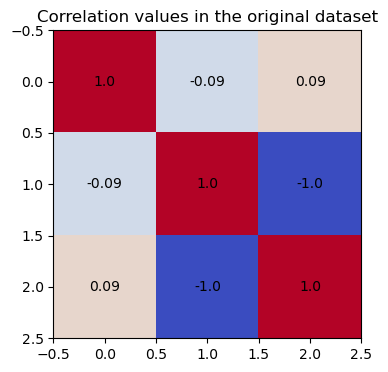

['age', 'sex_Female', 'sex_Male']


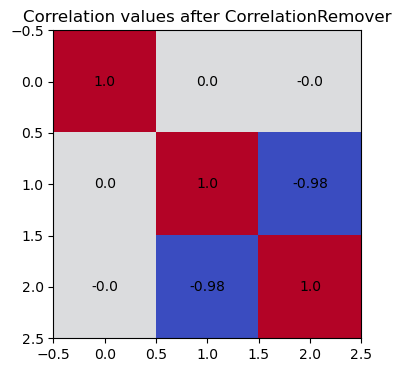

['age', 'sex_Female', 'sex_Male']


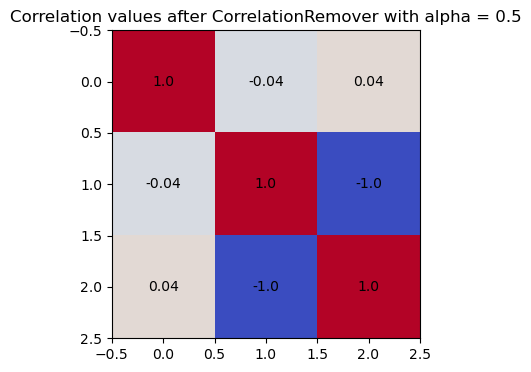

In [7]:
X_raw = adult_data.data[["age", "sex"]]
X_raw = pd.get_dummies(X_raw)
plot_heatmap(X_raw, "Correlation values in the original dataset")
cr = CorrelationRemover(sensitive_feature_ids=["sex_Male"])
X_cr = cr.fit_transform(X_raw)
X_cr = pd.DataFrame(X_cr, columns=['age', 'sex_Female'])
X_cr["sex_Male"] = X_raw["sex_Male"]
plot_heatmap(X_cr, "Correlation values after CorrelationRemover")
cr_alpha = CorrelationRemover(sensitive_feature_ids=['sex_Male'], alpha=0.5)
X_cr_alpha = cr_alpha.fit_transform(X_raw)
X_cr_alpha = pd.DataFrame(X_cr_alpha, columns=['age', 'sex_Female'])
X_cr_alpha["sex_Male"] = X_raw["sex_Male"]
plot_heatmap(X_cr_alpha, "Correlation values after CorrelationRemover with alpha = 0.5")

### **Exercise 1**
Modify the previous code with the aim of visualizing the fraction of people who earn over $50k regarding race. Then, plot correlations regarding age and race. Finally, remove correlations with alpha=0.7 for race_Black.

--- Metrics by group (Race) ---
                    selection_rate  true_positive_rate
race                                                  
Amer-Indian-Eskimo        0.117021                 1.0
Asian-Pac-Islander        0.269256                 1.0
Black                     0.120811                 1.0
Other                     0.123153                 1.0
White                     0.253987                 1.0

Maximum difference between groups: 0.15223481293684255
Minimum ratio between groups: 0.4346095822712376


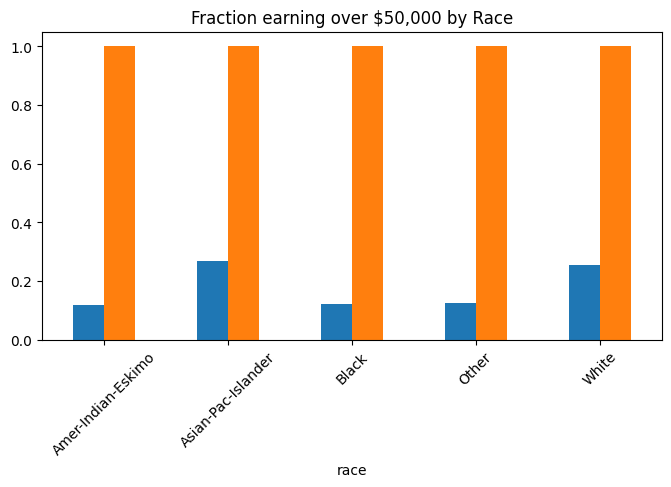

In [7]:
# 1. Fraction of people earning over $50k regarding race
metrics_dict = {"selection_rate": selection_rate, "true_positive_rate": true_positive_rate}

selection_rates_race = MetricFrame(
    metrics=metrics_dict, 
    y_true=y_true, 
    y_pred=y_true, 
    sensitive_features=race
)

print("--- Metrics by group (Race) ---")
print(selection_rates_race.by_group)
print("\nMaximum difference between groups:", selection_rates_race.difference()["selection_rate"])
print("Minimum ratio between groups:", selection_rates_race.ratio()["selection_rate"])

# Plotting the bar chart
fig_race = selection_rates_race.by_group.plot.bar(
    legend=False, 
    rot=45, # Rotate labels 45 degrees for better readability
    title="Fraction earning over $50,000 by Race",
    figsize=(8, 4)
)

['age', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White']


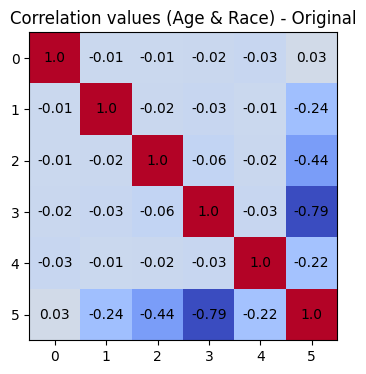

['age', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Other', 'race_White', 'race_Black']


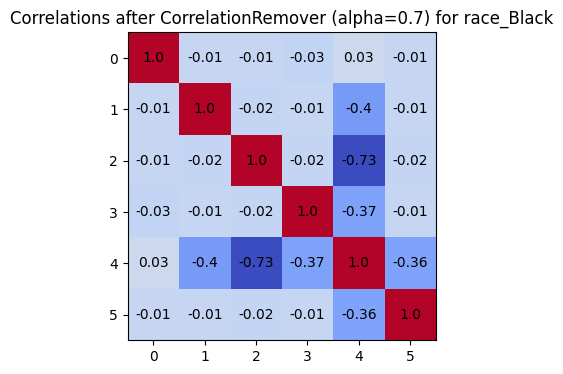

In [8]:
# 2. Correlations between age and race in the original dataset
X_raw_race = adult_data.data[["age", "race"]]
X_raw_race = pd.get_dummies(X_raw_race) # Convert race categories into 0/1 dummy columns

plot_heatmap(X_raw_race, "Correlation values (Age & Race) - Original")

# 3. Remove correlations with alpha=0.7 for race_Black
cr_alpha_race = CorrelationRemover(sensitive_feature_ids=['race_Black'], alpha=0.7)

# Apply the transformation
X_cr_alpha_race = cr_alpha_race.fit_transform(X_raw_race)

# When using CorrelationRemover, the 'race_Black' column is dropped from the result. 
# To rebuild the DataFrame and see the new heatmap, we extract the remaining column names:
cols_without_black = [col for col in X_raw_race.columns if col != 'race_Black']
X_cr_alpha_race_df = pd.DataFrame(X_cr_alpha_race, columns=cols_without_black)

# We add back the original 'race_Black' column to check in the heatmap 
# how the correlation with the other variables has decreased
X_cr_alpha_race_df["race_Black"] = X_raw_race["race_Black"]

plot_heatmap(X_cr_alpha_race_df, "Correlations after CorrelationRemover (alpha=0.7) for race_Black")

### **3.1 Building a fairness-unaware predictor**

Now, we are going to build a fairness-unaware predictor (LogisticRegression) and show how it leads to unfair decisions under a specific notion of fairness called [demographic parity](https://fairlearn.org/v0.8/api_reference/fairlearn.metrics.html#). We then mitigate unfairness by applying the GridSearch [fairlearn.reductions.GridSearch](https://fairlearn.org/v0.8/api_reference/fairlearn.reductions.html) algorithm.

In [9]:
A = sex
X = adult_data.data.drop(labels=["sex"], axis=1)
X = pd.get_dummies(X)

sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

le = LabelEncoder()
Y = le.fit_transform(y_true)
X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
    X_scaled, Y, A, test_size=0.25, random_state=0, stratify=Y
)

X_train = X_train.reset_index(drop=True)
A_train = A_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
A_test = A_test.reset_index(drop=True)

unmitigated_predictor = LogisticRegression(solver="liblinear", fit_intercept=True)
unmitigated_predictor.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Let us see how good the unmitigated predictor is from the ROC_AUC and Accuracy score viewpoint.

In [10]:
Y_pred_proba = unmitigated_predictor.predict_proba(X_test)[:, 1]
Y_pred = unmitigated_predictor.predict(X_test)
roc_auc_score(Y_test, Y_pred_proba)

0.9044675320120232

Let us assess the predictor’s fairness using the MetricFrame.
Please, look carefully at the disparity in accuracy: males have smaller accuracy than females. Nevertheless, the selection rate for males is greater than three times the rate for females (i.e., there is disparity in opportunity).

It is worth noting that despite the fact that we removed the feature sex from the training data, our predictor still discriminates based on sex. This demonstrates that simply ignoring a sensitive feature when fitting a predictor rarely eliminates unfairness. There will generally be enough other features correlated with the removed feature to lead to disparate impact.

accuracy                   0.854148
selection_rate             0.194988
true_positive_rate         0.602669
true_negative_rate         0.933254
false_positive_rate        0.602669
false_negative_rate        0.933254
count                  12211.000000
dtype: float64
        accuracy  selection_rate  true_positive_rate  true_negative_rate  \
sex                                                                        
Female  0.928150        0.077264            0.524554            0.978153   
Male    0.817233        0.253713            0.616815            0.904636   

        false_positive_rate  false_negative_rate   count  
sex                                                       
Female             0.524554             0.978153  4064.0  
Male               0.616815             0.904636  8147.0  


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'true_positive_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'true_negative_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'false_positive_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'false_negative_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

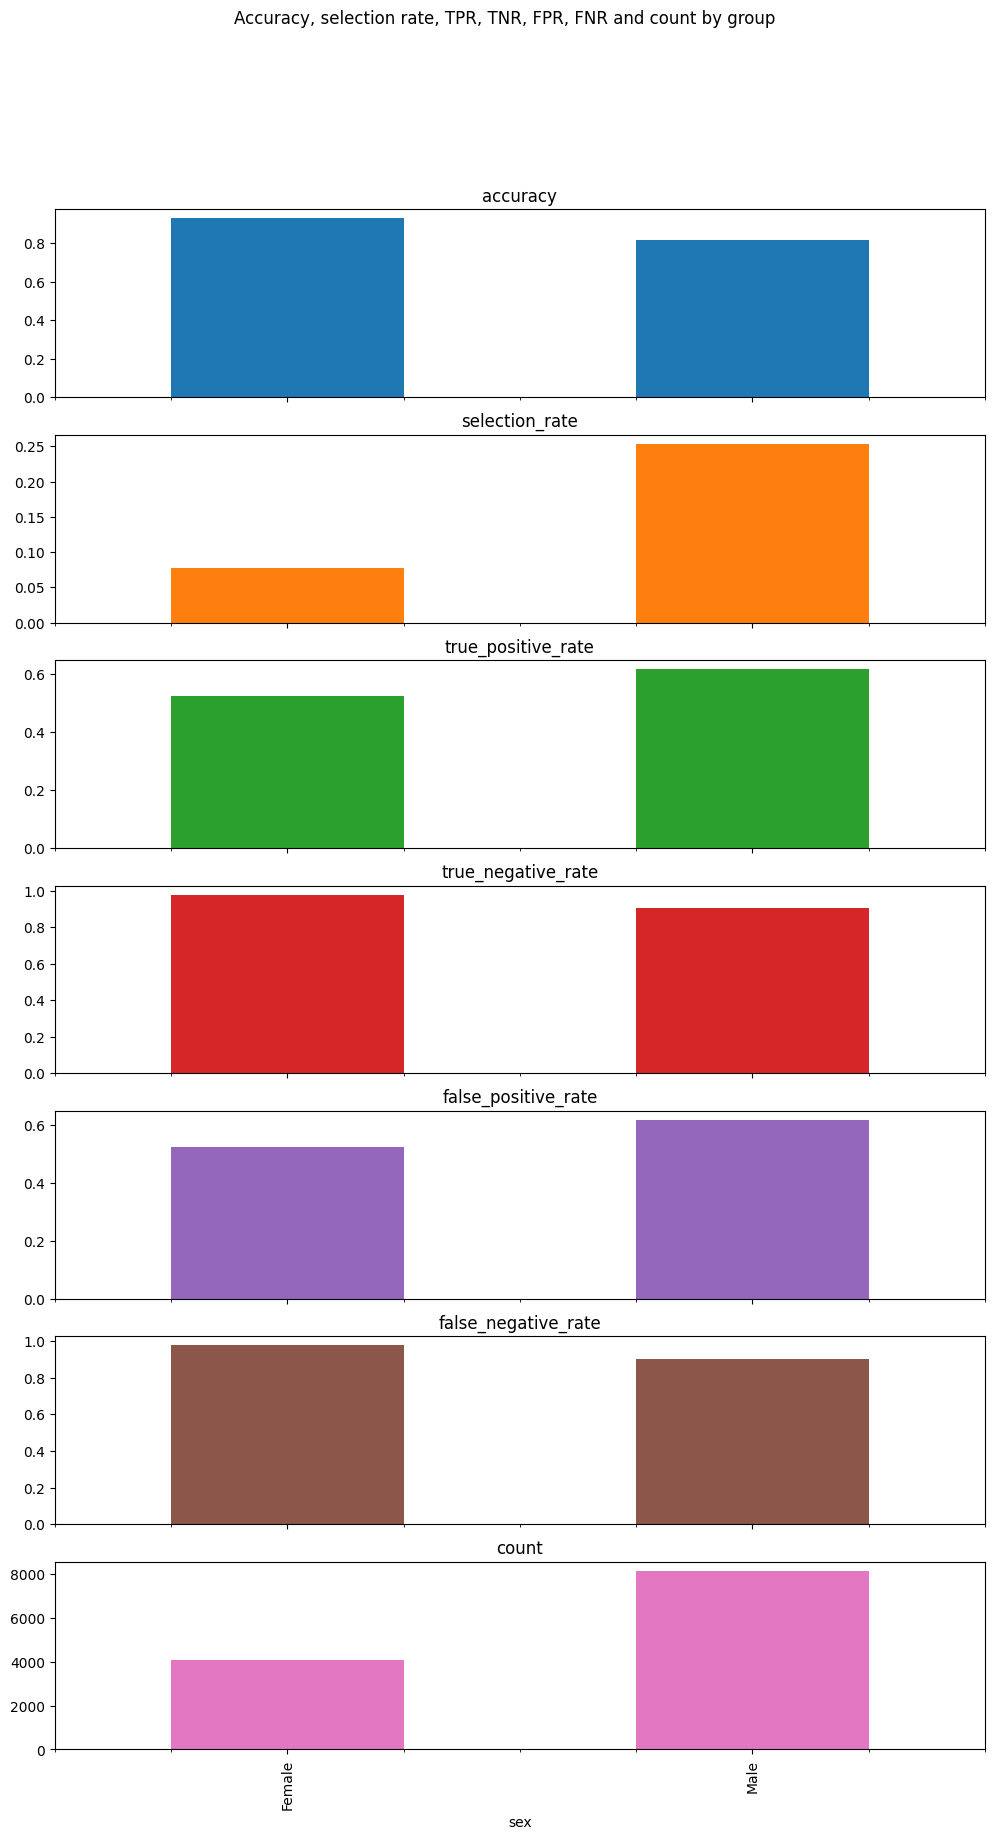

In [11]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "true_negative_rate": true_negative_rate,
        "false_positive_rate": true_positive_rate,
        "false_negative_rate": true_negative_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=unmitigated_predictor.predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[7, 1],
    legend=False,
    figsize=[12, 20],
    title="Accuracy, selection rate, TPR, TNR, FPR, FNR and count by group",
)

### **Exercise 2**
Repeat the previous analysis but considering now education as sensitive feature. Pay special attention to HS-grad versus Masters and comment the observed results.

accuracy                   0.853738
selection_rate             0.196380
true_positive_rate         0.604723
true_negative_rate         0.932070
false_positive_rate        0.067930
false_negative_rate        0.395277
count                  12211.000000
dtype: float64
           accuracy  selection_rate  true_positive_rate  true_negative_rate  \
education                                                                     
HS-grad    0.859494        0.064051            0.253268            0.970641   
Masters    0.808955        0.628358            0.870886            0.720000   

           false_positive_rate  false_negative_rate   count  
education                                                    
HS-grad               0.029359             0.746732  3950.0  
Masters               0.280000             0.129114   670.0  


array([[<Axes: title={'center': 'accuracy'}, xlabel='education'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'true_positive_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'true_negative_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'false_positive_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'false_negative_rate'}, xlabel='education'>],
       [<Axes: title={'center': 'count'}, xlabel='education'>]],
      dtype=object)

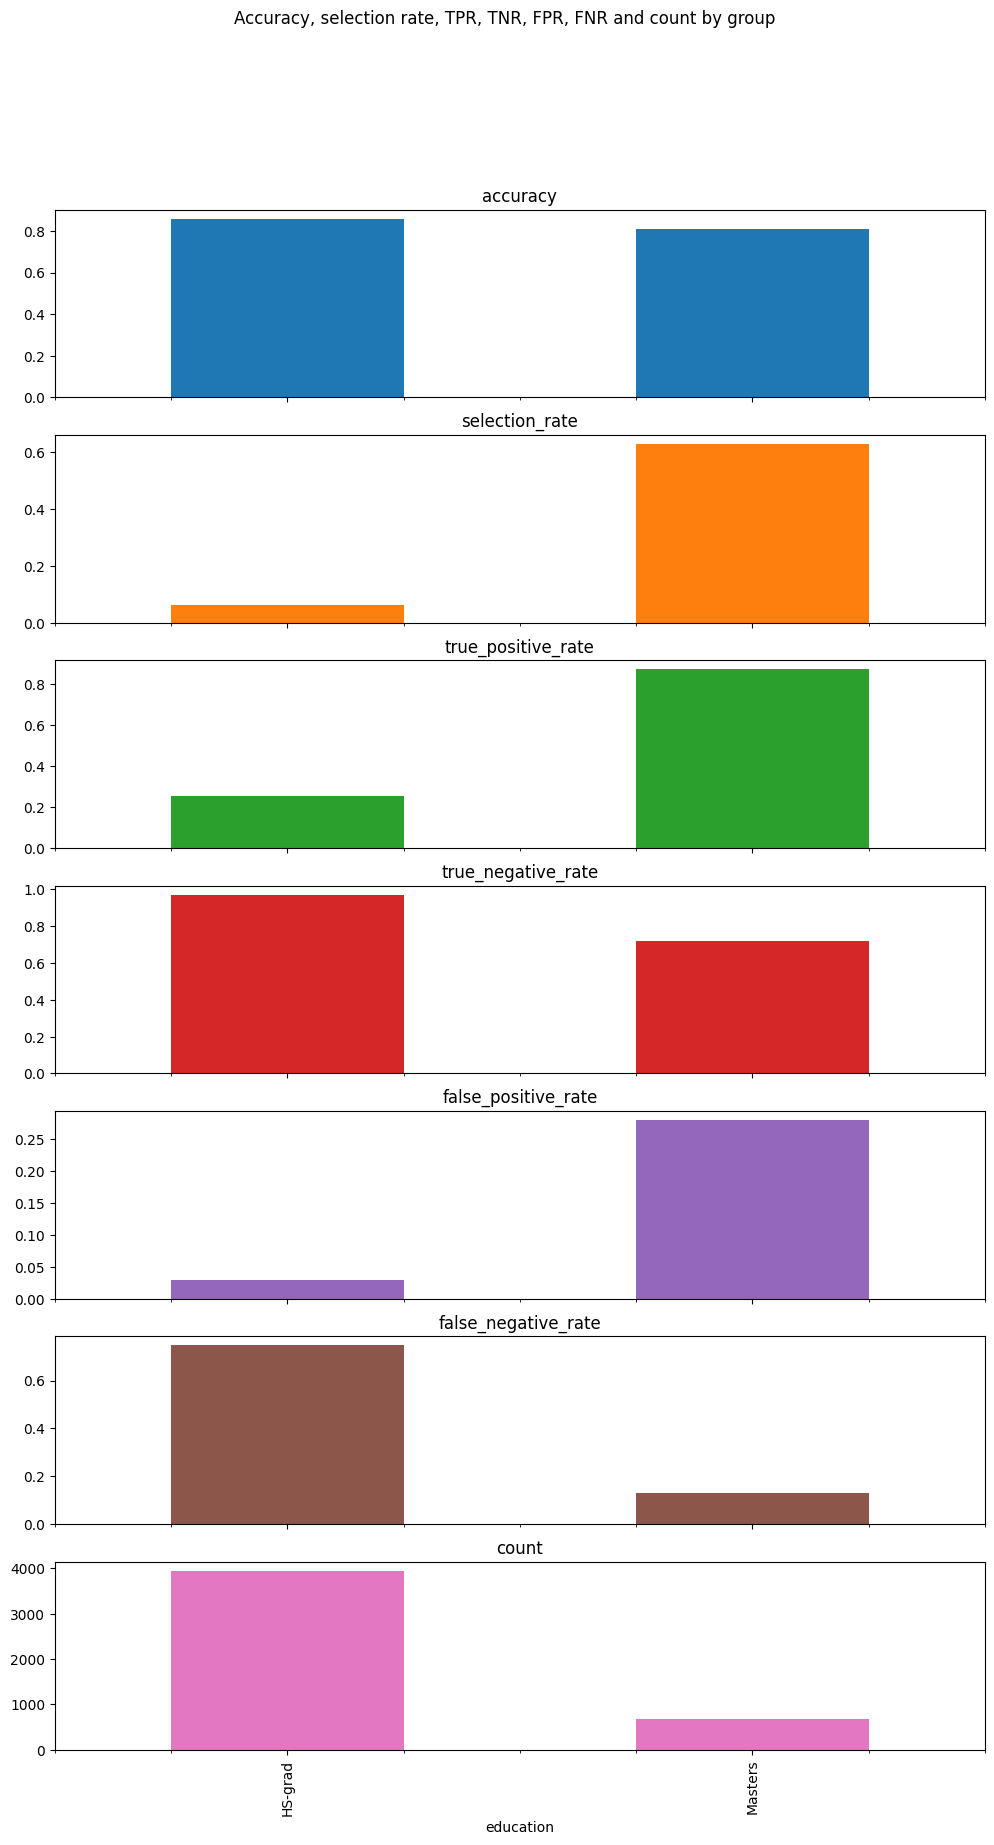

In [24]:
A_edu = adult_data.data['education']
X_edu = adult_data.data.drop(labels=["education"], axis=1)
X_edu = pd.get_dummies(X_edu)

sc = StandardScaler()
X_scaled_edu = sc.fit_transform(X_edu)
X_scaled_edu = pd.DataFrame(X_scaled_edu, columns=X_edu.columns)

le = LabelEncoder()
Y_edu = le.fit_transform(y_true)

X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
    X_scaled_edu, Y_edu, A_edu, test_size=0.25, random_state=0, stratify=Y_edu
)

X_train = X_train.reset_index(drop=True)
A_train = A_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
A_test = A_test.reset_index(drop=True)

unmitigated_predictor_edu = LogisticRegression(solver="liblinear", fit_intercept=True)
unmitigated_predictor_edu.fit(X_train, Y_train)

Y_pred = unmitigated_predictor_edu.predict(X_test)

metrics_dict = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "true_positive_rate": true_positive_rate,
    "true_negative_rate": true_negative_rate,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
    "count": count
}

metric_frame_edu = MetricFrame(
    metrics=metrics_dict, y_true=Y_test, y_pred=Y_pred, sensitive_features=A_test
)
print(metric_frame_edu.overall)
print(metric_frame_edu.by_group.loc[['HS-grad', 'Masters']])

metric_frame_edu.by_group.loc[['HS-grad', 'Masters']].plot.bar(
    subplots=True,
    layout=[7, 1],
    legend=False,
    figsize=[12, 20],
    title="Accuracy, selection rate, TPR, TNR, FPR, FNR and count by group",
)

The results reveal a severe bias favoring individuals with a Master's degree over High School graduates, despite removing education from the training data. There is a massive disparate impact, with the model predicting high income for nearly 63% of Master's holders compared to just 6.4% of HS graduates. Furthermore, the model exhibits a stark disparity in opportunity by correctly identifying 87% of actual high-earning Master's holders while missing almost 75% of actual high-earning HS graduates. The model is also far more likely to generously, yet incorrectly, guess a high income for a Master's holder (28% False Positive Rate) than for an HS graduate (under 3%). The slightly higher overall accuracy for HS graduates is merely a statistical illusion caused by the model aggressively predicting the negative class for this larger group. Ultimately, dropping the sensitive feature failed, as the model clearly reconstructed the education bias through other correlated proxy variables.

### **3.2 Mitigating bias: relabelling and reweighting**
We consider Demographic Parity (DP) on the sensitive feature sex as the fairness metric. DP requires that all individuals (no matter if they are males or females) are offered the same opportunity. We are going to remove the predictors which are dominated in the error-disparity space by others from the sweep which is defined below. Be patient because fitting the sweep may take long.

In [25]:
A = adult_data.data[['sex']] #sensitive feature
X = adult_data.data.drop(labels=['sex'], axis=1)
X = pd.get_dummies(X)
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
le = LabelEncoder()
Y = le.fit_transform(y_true)
X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
    X_scaled, Y, A, test_size=0.25, random_state=0, stratify=Y
)
X_train = X_train.reset_index(drop=True)
A_train = A_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
A_test = A_test.reset_index(drop=True)
unmitigated_predictor = LogisticRegression(solver="liblinear", fit_intercept=True)
unmitigated_predictor.fit(X_train, Y_train)
sweep = GridSearch(
    LogisticRegression(solver="liblinear", fit_intercept=True),
    constraints=DemographicParity(),
    grid_size=31,
)

sweep.fit(X_train, Y_train, sensitive_features=A_train)
predictors = sweep.predictors_
errors, disparities = [], []
for m in predictors:

    def classifier(X):
        return m.predict(X)

    error = ErrorRate()
    error.load_data(X_train, pd.Series(Y_train), sensitive_features=A_train)
    disparity = DemographicParity()
    disparity.load_data(X_train, pd.Series(Y_train), sensitive_features=A_train)

    errors.append(error.gamma(classifier)[0])
    disparities.append(disparity.gamma(classifier).max())

all_results = pd.DataFrame(
    {"predictor": predictors, "error": errors, "disparity": disparities}
)

non_dominated = []
for row in all_results.itertuples():
    errors_for_lower_or_eq_disparity = all_results["error"][
        all_results["disparity"] <= row.disparity
    ]
    if row.error <= errors_for_lower_or_eq_disparity.min():
        non_dominated.append(row.predictor)

Let us now compare graphically the non-dominated models.

Text(0, 0.5, 'selection rate difference')

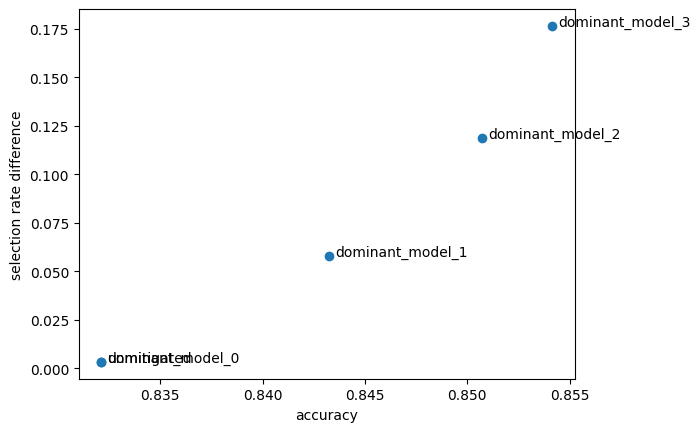

In [26]:
predictions = {"unmitigated": unmitigated_predictor.predict(X_test)}
metric_frames = {"unmitigated": metric_frame}
for i in range(len(non_dominated)):
    key = "dominant_model_{0}".format(i)
    predictions[key] = non_dominated[i].predict(X_test)

    metric_frames[key] = MetricFrame(
        metrics={
            "accuracy": skm.accuracy_score,
            "selection_rate": selection_rate,
            "count": count,
        },
        sensitive_features=A_test,
        y_true=Y_test,
        y_pred=predictions[key],
    )

x = [metric_frame.overall["accuracy"] for metric_frame in metric_frames.values()]
y = [
    metric_frame.difference()["selection_rate"]
    for metric_frame in metric_frames.values()
]
keys = list(metric_frames.keys())
plt.scatter(x, y)
for i in range(len(x)):
    plt.annotate(keys[i], (x[i] + 0.0003, y[i]))
plt.xlabel("accuracy")
plt.ylabel("selection rate difference")

With the code below, you can visualize the quality of the non-dominated models. Just change the id in y_pred=non_dominated[i].predict(X_test) with i in [0, 3]. Pay special attention to the comparison of Male versus Female regarding the selection_rate.

accuracy              0.832119
selection_rate        0.151994
count             12211.000000
dtype: float64
        accuracy  selection_rate   count
sex                                     
Female  0.898868        0.149852  4064.0
Male    0.798822        0.153062  8147.0


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: title={'center': 'count'}, xlabel='sex'>]], dtype=object)

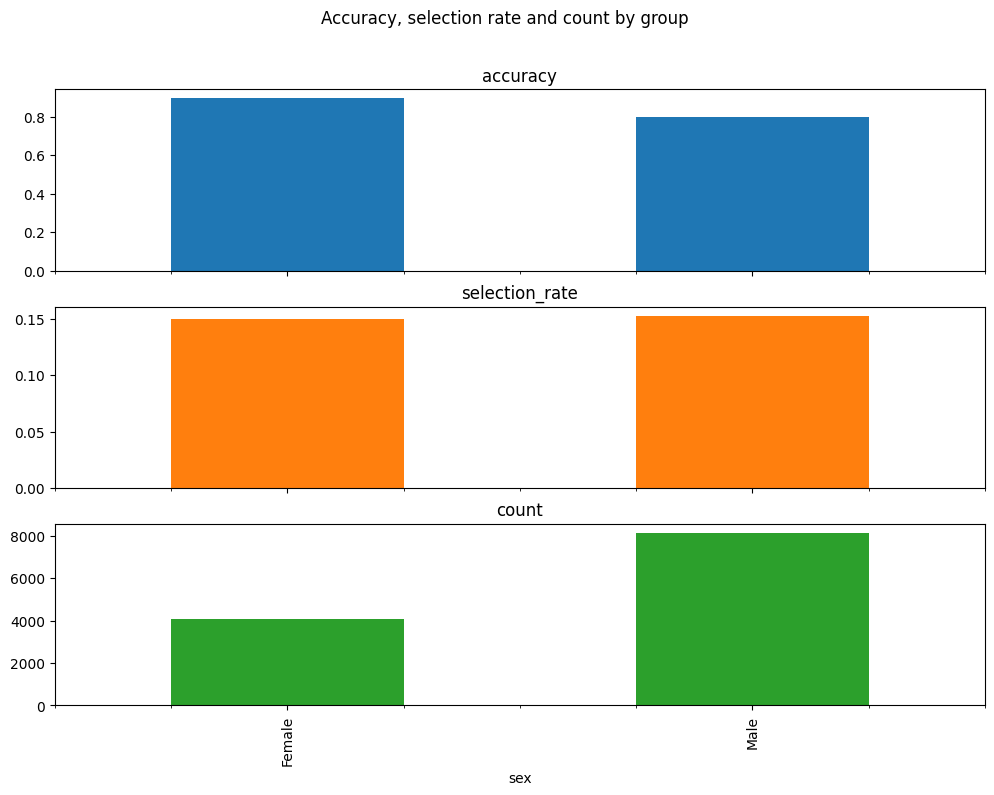

In [27]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": skm.accuracy_score,
        "selection_rate": selection_rate,
        "count": count,
    },
    sensitive_features=A_test,
    y_true=Y_test,
    y_pred=non_dominated[0].predict(X_test),
)
print(metric_frame.overall)
print(metric_frame.by_group)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

### **Exercise 3**
Compare the quality of the models with and without mitigating demographic bias regarding sex. Discuss the observed difference.

In [28]:
Y_pred_unmitigated = unmitigated_predictor.predict(X_test)

metrics_dict = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
}

metric_frame_unmitigated = MetricFrame(
    metrics=metrics_dict, y_true=Y_test, y_pred=Y_pred_unmitigated, sensitive_features=A_test
)

mitigator_sex = GridSearch(
    estimator=LogisticRegression(solver="liblinear", fit_intercept=True),
    constraints=DemographicParity(),
    grid_size=20,
)
mitigator_sex.fit(X_train, Y_train, sensitive_features=A_train)

predictors_sex = mitigator_sex.predictors_
disparities = []

for p in predictors_sex:
    y_pred_temp = p.predict(X_test)
    mf_temp = MetricFrame(metrics=selection_rate, y_true=Y_test, y_pred=y_pred_temp, sensitive_features=A_test)
    disparities.append(mf_temp.difference())

best_idx = disparities.index(min(disparities))
best_predictor_sex = predictors_sex[best_idx]

Y_pred_mitigated = best_predictor_sex.predict(X_test)

metric_frame_mitigated = MetricFrame(
    metrics=metrics_dict, y_true=Y_test, y_pred=Y_pred_mitigated, sensitive_features=A_test
)

print("--- UNMITIGATED MODEL (SEX) ---")
print(metric_frame_unmitigated.by_group)
print(f"Overall Accuracy: {accuracy_score(Y_test, Y_pred_unmitigated):.4f}")
print(f"Selection Rate Difference: {metric_frame_unmitigated.difference()['selection_rate']:.4f}\n")

print("--- MITIGATED MODEL (SEX) ---")
print(metric_frame_mitigated.by_group)
print(f"Overall Accuracy: {accuracy_score(Y_test, Y_pred_mitigated):.4f}")
print(f"Selection Rate Difference: {metric_frame_mitigated.difference()['selection_rate']:.4f}")

--- UNMITIGATED MODEL (SEX) ---
        accuracy  selection_rate
sex                             
Female  0.928150        0.077264
Male    0.817233        0.253713
Overall Accuracy: 0.8541
Selection Rate Difference: 0.1764

--- MITIGATED MODEL (SEX) ---
        accuracy  selection_rate
sex                             
Female  0.898868        0.149852
Male    0.798822        0.153062
Overall Accuracy: 0.8321
Selection Rate Difference: 0.0032


array([[<Axes: title={'center': 'accuracy'}, xlabel='sex'>],
       [<Axes: title={'center': 'selection_rate'}, xlabel='sex'>],
       [<Axes: xlabel='sex'>]], dtype=object)

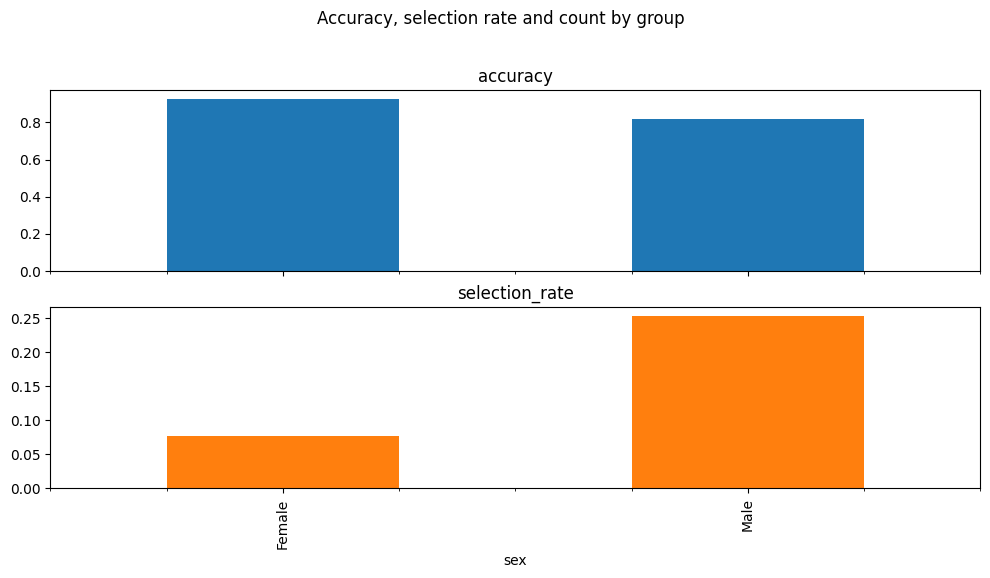

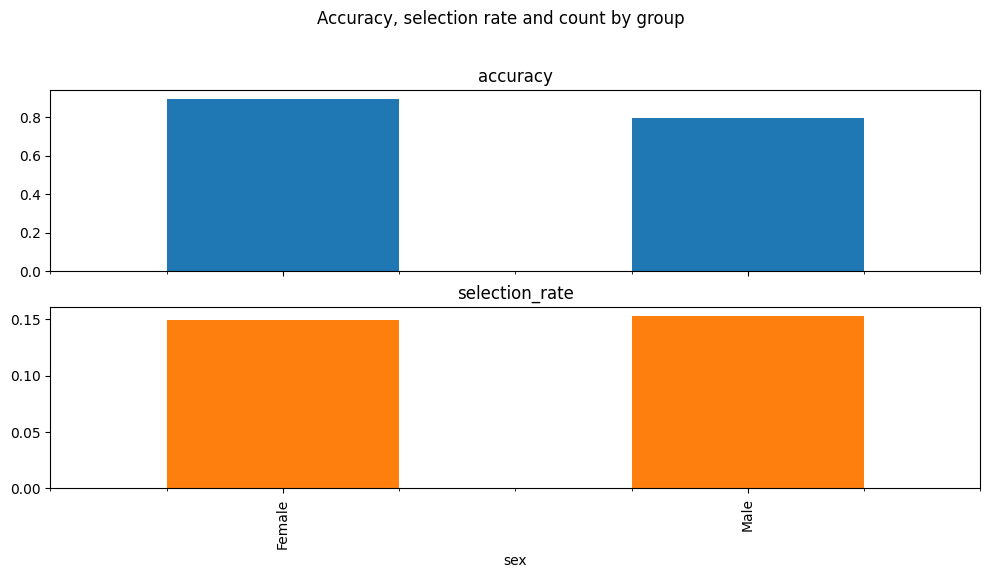

In [31]:
metric_frame_unmitigated.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

metric_frame_mitigated.by_group.plot.bar(
    subplots=True,
    layout=[3, 1],
    legend=False,
    figsize=[12, 8],
    title="Accuracy, selection rate and count by group",
)

The results illustrate the classic fairness-accuracy trade-off. In the unmitigated model, there is a clear demographic bias, with males being predicted for high income at a significantly higher rate than females. After applying the Demographic Parity constraint, the mitigated model successfully balances these selection rates, ensuring both genders receive nearly equal opportunities for positive predictions. However, achieving this equitable outcome requires a mathematical compromise, resulting in a slight drop in the model's overall accuracy compared to the biased baseline.